# Delinquency Prediction: Exploratory Analysis and Risk Indicators

This notebook reviews the delinquency prediction dataset, checks data structure and quality, and identifies customer patterns that may influence delinquency outcomes.

## Objective

- Understand the dataset structure and completeness.
- Clean obvious data inconsistencies that could affect prediction.
- Analyze relationships between customer variables and delinquency.
- Surface high-risk indicators and unexpected trends for the analytics team.

## 1. Setup

Import the required Python libraries for data analysis and visualization.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from matplotlib.ticker import PercentFormatter

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## 2. Load Dataset

Load the cleaned delinquency prediction dataset and preview the first few records.

In [22]:
df = pd.read_csv("Delinquency_prediction_dataset.csv")
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.000,398.000,0.391,3,0,16310.000,0.317,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.000,493.000,0.312,6,1,17401.000,0.196,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.000,500.000,0.360,0,0,13761.000,0.302,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.000,413.000,0.371,3,0,88778.000,0.265,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.000,487.000,0.235,2,0,13316.000,0.511,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


### Initial Preview Summary

The dataset contains customer demographics, financial variables, product details, location, monthly payment statuses, and the target variable `Delinquent_Account`.

In [23]:
df.tail()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
495,CUST0496,71,48307.000,688.000,0.487,2,0,12707.000,0.373,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180.000,836.000,0.608,2,1,45595.000,0.292,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326.000,847.000,0.677,0,0,44449.000,0.105,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852.000,343.000,0.701,2,1,11155.000,0.236,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed
499,CUST0500,25,40945.000,442.000,0.911,1,0,36968.000,0.370,Self-employed,0,Business,Houston,Missed,Late,Late,On-time,Late,On-time


## 3. Dataset Structure

Check the number of rows and columns, column names, data types, and basic descriptive statistics.

In [24]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.columns.tolist()

Rows: 500
Columns: 19


['Customer_ID',
 'Age',
 'Income',
 'Credit_Score',
 'Credit_Utilization',
 'Missed_Payments',
 'Delinquent_Account',
 'Loan_Balance',
 'Debt_to_Income_Ratio',
 'Employment_Status',
 'Account_Tenure',
 'Credit_Card_Type',
 'Location',
 'Month_1',
 'Month_2',
 'Month_3',
 'Month_4',
 'Month_5',
 'Month_6']

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [26]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000,461.000,498.000,500.000,500.000,500.000,471.000,500.000,500.000
mean,46.266,108379.894,577.717,0.491,2.968,0.160,48654.429,0.299,9.740
std,16.188,53662.724,168.881,0.197,1.947,0.367,29395.537,0.095,5.923
min,18.000,15404.000,301.000,0.050,0.000,0.000,612.000,0.100,0.000
25%,33.000,62295.000,418.250,0.356,1.000,0.000,23716.500,0.234,5.000
50%,46.500,107658.000,586.000,0.486,3.000,0.000,45776.000,0.302,10.000
75%,59.250,155734.000,727.250,0.634,5.000,0.000,75546.500,0.363,15.000
max,74.000,199943.000,847.000,1.026,6.000,1.000,99620.000,0.553,19.000


## 4. Completeness and Data Quality

Check missing values and obvious inconsistencies that may affect downstream delinquency prediction.

In [27]:
df.isnull().sum()

Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64

In [28]:
quality_checks = pd.DataFrame({
    'Issue': [
        'Zero income values',
        'Zero credit score values',
        'Zero loan balance values',
        'Employment label variations'
    ],
    'Count_or_Values': [
        (df['Income'] == 0).sum(),
        (df['Credit_Score'] == 0).sum(),
        (df['Loan_Balance'] == 0).sum(),
        ', '.join(sorted(df['Employment_Status'].dropna().unique()))
    ]
})
quality_checks

,Issue,Count_or_Values
0,Zero income values,0
1,Zero credit score values,0
2,Zero loan balance values,0
3,Employment label variations,"EMP, Employed, Self-employed, Unemployed, empl..."


## 5. Cleaning Steps

Fill missing numeric values with the median and standardize inconsistent employment labels for analysis. Zero values are flagged above because they may represent either valid values or encoded missing data, so they should be reviewed before final modeling.

In [29]:
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Loan_Balance'] = df['Loan_Balance'].fillna(df['Loan_Balance'].median())

df['Employment_Status_Clean'] = df['Employment_Status'].replace({
    'EMP': 'Employed',
    'employed': 'Employed',
    'retired': 'Retired'
})

df.isnull().sum()

Customer_ID                0
Age                        0
Income                     0
Credit_Score               0
Credit_Utilization         0
Missed_Payments            0
Delinquent_Account         0
Loan_Balance               0
Debt_to_Income_Ratio       0
Employment_Status          0
Account_Tenure             0
Credit_Card_Type           0
Location                   0
Month_1                    0
Month_2                    0
Month_3                    0
Month_4                    0
Month_5                    0
Month_6                    0
Employment_Status_Clean    0
dtype: int64

## 6. Target Variable Overview

The target variable is `Delinquent_Account`, where `1` indicates a delinquent account and `0` indicates a non-delinquent account.

In [30]:
target = 'Delinquent_Account'
baseline_rate = df[target].mean()

target_summary = df[target].value_counts().rename_axis('Delinquent_Account').reset_index(name='Records')
target_summary['Share'] = target_summary['Records'] / len(df)

print(f"Overall delinquency rate: {baseline_rate:.1%}")
target_summary

Overall delinquency rate: 16.0%


,Delinquent_Account,Records,Share
0,0,420,0.840
1,1,80,0.160


## 7. Feature Engineering for Payment Behavior

Create simple behavior features from the six monthly payment status columns. These features summarize missed and late behavior across the customer history.

In [31]:
monthly_cols = [f'Month_{i}' for i in range(1, 7)]

df['Missed_Month_Count'] = (df[monthly_cols] == 'Missed').sum(axis=1)
df['Late_Month_Count'] = (df[monthly_cols] == 'Late').sum(axis=1)
df['Late_or_Missed_Count'] = df[monthly_cols].isin(['Late', 'Missed']).sum(axis=1)
df['Recent_Late_Count'] = (df[['Month_4', 'Month_5', 'Month_6']] == 'Late').sum(axis=1)
df['Recent_Missed_Count'] = (df[['Month_4', 'Month_5', 'Month_6']] == 'Missed').sum(axis=1)

df[['Missed_Month_Count', 'Late_Month_Count', 'Late_or_Missed_Count', 'Recent_Late_Count', 'Recent_Missed_Count']].describe()

,Missed_Month_Count,Late_Month_Count,Late_or_Missed_Count,Recent_Late_Count,Recent_Missed_Count
count,500.000,500.000,500.000,500.000,500.000
mean,2.016,2.010,4.026,1.008,1.030
std,1.118,1.092,1.140,0.803,0.816
min,0.000,0.000,1.000,0.000,0.000
25%,1.000,1.000,3.000,0.000,0.000
50%,2.000,2.000,4.000,1.000,1.000
75%,3.000,3.000,5.000,2.000,2.000
max,6.000,6.000,6.000,3.000,3.000


## 8. Numeric Relationships with Delinquency

Use correlations to identify which numeric variables move most strongly with delinquency. Correlation is only a first-pass signal, so weak or counterintuitive results should be validated with grouped rates and business review.

In [32]:
numeric_features = [
    'Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments',
    'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure',
    'Missed_Month_Count', 'Late_Month_Count', 'Late_or_Missed_Count',
    'Recent_Late_Count', 'Recent_Missed_Count'
]

numeric_relationships = (
    df[numeric_features + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
numeric_relationships.columns = ['Variable', 'Correlation_with_Delinquency']
numeric_relationships

,Variable,Correlation_with_Delinquency
0,Income,0.044
1,Recent_Late_Count,0.043
2,Account_Tenure,-0.040
3,Credit_Score,0.035
4,Debt_to_Income_Ratio,0.034
5,Credit_Utilization,0.034
6,Missed_Payments,-0.026
7,Late_or_Missed_Count,-0.024
8,Late_Month_Count,-0.024
9,Age,0.023


### Numeric Relationship Summary

Most individual numeric variables have weak correlation with delinquency in this sample. This suggests the model may need categorical features, binned variables, and interaction effects rather than relying only on simple linear relationships.

## 9. Categorical Risk Patterns

Compare delinquency rates across employment status, credit card type, location, and monthly payment status categories.

In [33]:
def delinquency_rate_table(data, group_col):
    summary = (
        data.groupby(group_col, observed=False)[target]
        .agg(Records='count', Delinquency_Rate='mean')
        .reset_index()
        .sort_values('Delinquency_Rate', ascending=False)
    )
    summary['Lift_vs_Baseline'] = summary['Delinquency_Rate'] / baseline_rate
    return summary

category_features = ['Employment_Status_Clean', 'Credit_Card_Type', 'Location'] + monthly_cols

category_risk_tables = {
    feature: delinquency_rate_table(df, feature)
    for feature in category_features
}

category_risk_tables['Credit_Card_Type']

,Credit_Card_Type,Records,Delinquency_Rate,Lift_vs_Baseline
0,Business,108,0.213,1.331
4,Student,112,0.179,1.116
1,Gold,118,0.144,0.900
3,Standard,86,0.128,0.799
2,Platinum,76,0.118,0.740


In [34]:
display(category_risk_tables['Employment_Status_Clean'])
display(category_risk_tables['Location'])

,Employment_Status_Clean,Records,Delinquency_Rate,Lift_vs_Baseline
3,Unemployed,93,0.194,1.210
0,Employed,240,0.163,1.016
2,Self-employed,80,0.163,1.016
1,Retired,87,0.115,0.718


,Location,Records,Delinquency_Rate,Lift_vs_Baseline
2,Los Angeles,107,0.196,1.227
1,Houston,95,0.168,1.053
4,Phoenix,103,0.165,1.032
0,Chicago,103,0.146,0.910
3,New York,92,0.120,0.747


In [36]:
for month in monthly_cols:
    print(f"{month}")
    display(category_risk_tables[month])

Month_1


,Month_1,Records,Delinquency_Rate,Lift_vs_Baseline
2,On-time,177,0.198,1.236
1,Missed,164,0.165,1.029
0,Late,159,0.113,0.708


Month_2


,Month_2,Records,Delinquency_Rate,Lift_vs_Baseline
2,On-time,160,0.175,1.094
1,Missed,167,0.156,0.973
0,Late,173,0.150,0.939


Month_3


...

,Month_4,Records,Delinquency_Rate,Lift_vs_Baseline
0,Late,181,0.193,1.209
1,Missed,160,0.169,1.055
2,On-time,159,0.113,0.708


Month_5


,Month_5,Records,Delinquency_Rate,Lift_vs_Baseline
0,Late,151,0.192,1.200
2,On-time,162,0.160,1.003
1,Missed,187,0.134,0.836


Month_6


,Month_6,Records,Delinquency_Rate,Lift_vs_Baseline
2,On-time,160,0.181,1.133
1,Missed,168,0.167,1.042
0,Late,172,0.134,0.836


### Categorical Pattern Summary

Business card customers, unemployed customers, and Los Angeles customers show above-baseline delinquency. Monthly payment statuses are mixed, which is a warning sign that the status fields should be validated before model training.

## 10. Binned Numeric Risk Patterns

Bin numeric variables into quartiles to identify non-linear patterns that may not appear in simple correlations.

In [37]:
binned_features = [
    'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
    'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure'
]

binned_results = []
for feature in binned_features:
    band_col = f'{feature}_Band'
    df[band_col] = pd.qcut(df[feature], q=4, duplicates='drop')
    temp = delinquency_rate_table(df, band_col)
    temp.insert(0, 'Variable', feature)
    temp = temp.rename(columns={band_col: 'Band'})
    binned_results.append(temp)

binned_risk_summary = pd.concat(binned_results, ignore_index=True)
binned_risk_summary.sort_values('Delinquency_Rate', ascending=False).head(15)

,Variable,Band,Records,Delinquency_Rate,Lift_vs_Baseline
0,Age,"(46.5, 59.25]",125,0.224,1.400
28,Account_Tenure,"(5.0, 10.0]",117,0.197,1.229
4,Income,"(107658.0, 152572.25]",103,0.194,1.214
8,Credit_Score,"(586.0, 725.75]",124,0.185,1.159
16,Missed_Payments,"(-0.001, 1.0]",131,0.183,1.145
29,Account_Tenure,"(15.0, 19.0]",115,0.183,1.141
17,Missed_Payments,"(3.0, 5.0]",151,0.179,1.118
9,Credit_Score,"(725.75, 847.0]",125,0.176,1.100
12,Credit_Utilization,"(0.356, 0.486]",125,0.176,1.100
25,Debt_to_Income_Ratio,"(0.363, 0.553]",125,0.176,1.100


### Binned Pattern Summary

The age 47-59 band, middle-high income band, low account tenure band, and high DTI band appear above baseline. Some expected patterns, such as lower credit score leading to higher delinquency, are not strong in this sample.

## 11. High-Risk Flags

Create interpretable risk flags that can be used to prioritize variables for a delinquency prediction model.

In [38]:
risk_flags = pd.DataFrame({
    'Low_Tenure': df['Account_Tenure'] < df['Account_Tenure'].quantile(0.25),
    'High_Utilization': df['Credit_Utilization'] >= df['Credit_Utilization'].quantile(0.75),
    'High_DTI': df['Debt_to_Income_Ratio'] >= df['Debt_to_Income_Ratio'].quantile(0.75),
    'Low_Credit_Score': df['Credit_Score'] < df['Credit_Score'].quantile(0.25),
    'High_Loan_Balance': df['Loan_Balance'] >= df['Loan_Balance'].quantile(0.75),
    'Unemployed': df['Employment_Status_Clean'] == 'Unemployed',
    'Business_Card': df['Credit_Card_Type'] == 'Business',
    'Los_Angeles': df['Location'] == 'Los Angeles',
    'Age_47_to_59': df['Age'].between(df['Age'].quantile(0.50), df['Age'].quantile(0.75), inclusive='left'),
    'Recent_Late': df['Recent_Late_Count'] > 0,
    'Recent_Missed': df['Recent_Missed_Count'] > 0,
    'Missed_Payments_5Plus': df['Missed_Payments'] >= 5
})

single_flag_summary = []
for flag in risk_flags.columns:
    subset = df[risk_flags[flag]]
    single_flag_summary.append({
        'Risk_Flag': flag,
        'Records': len(subset),
        'Delinquency_Rate': subset[target].mean(),
        'Lift_vs_Baseline': subset[target].mean() / baseline_rate
    })

single_flag_summary = pd.DataFrame(single_flag_summary).sort_values('Delinquency_Rate', ascending=False)
single_flag_summary

,Risk_Flag,Records,Delinquency_Rate,Lift_vs_Baseline
8,Age_47_to_59,125,0.224,1.400
6,Business_Card,108,0.213,1.331
7,Los_Angeles,107,0.196,1.227
0,Low_Tenure,123,0.195,1.220
5,Unemployed,93,0.194,1.210
2,High_DTI,125,0.176,1.100
9,Recent_Late,359,0.173,1.079
11,Missed_Payments_5Plus,129,0.171,1.066
1,High_Utilization,125,0.168,1.050
4,High_Loan_Balance,125,0.160,1.000


## 12. Interaction Effects

Analyze pairs of risk flags to find customer segments where delinquency risk is much higher than the overall baseline.

In [39]:
combo_results = []
for flag_a, flag_b in combinations(risk_flags.columns, 2):
    mask = risk_flags[flag_a] & risk_flags[flag_b]
    subset = df[mask]
    if len(subset) >= 20:
        combo_results.append({
            'Risk_Combination': f'{flag_a} + {flag_b}',
            'Records': len(subset),
            'Delinquency_Rate': subset[target].mean(),
            'Lift_vs_Baseline': subset[target].mean() / baseline_rate
        })

combo_risk_summary = pd.DataFrame(combo_results).sort_values('Delinquency_Rate', ascending=False)
combo_risk_summary.head(20)

,Risk_Combination,Records,Delinquency_Rate,Lift_vs_Baseline
6,Low_Tenure + Los_Angeles,22,0.364,2.273
45,Unemployed + Business_Card,21,0.333,2.083
41,High_Loan_Balance + Age_47_to_59,34,0.324,2.022
39,High_Loan_Balance + Business_Card,22,0.318,1.989
7,Low_Tenure + Age_47_to_59,32,0.312,1.953
40,High_Loan_Balance + Los_Angeles,24,0.292,1.823
24,High_DTI + Business_Card,28,0.286,1.786
23,High_DTI + Unemployed,21,0.286,1.786
52,Business_Card + Age_47_to_59,29,0.276,1.724
25,High_DTI + Los_Angeles,22,0.273,1.705


### Interaction Summary

Several combinations show materially higher delinquency than the portfolio average. These interaction features are important because single-variable relationships are weak, but paired customer characteristics reveal clearer high-risk segments.

## 13. Visual Summary

Visualize key delinquency-rate patterns and compare them with the overall baseline delinquency rate.

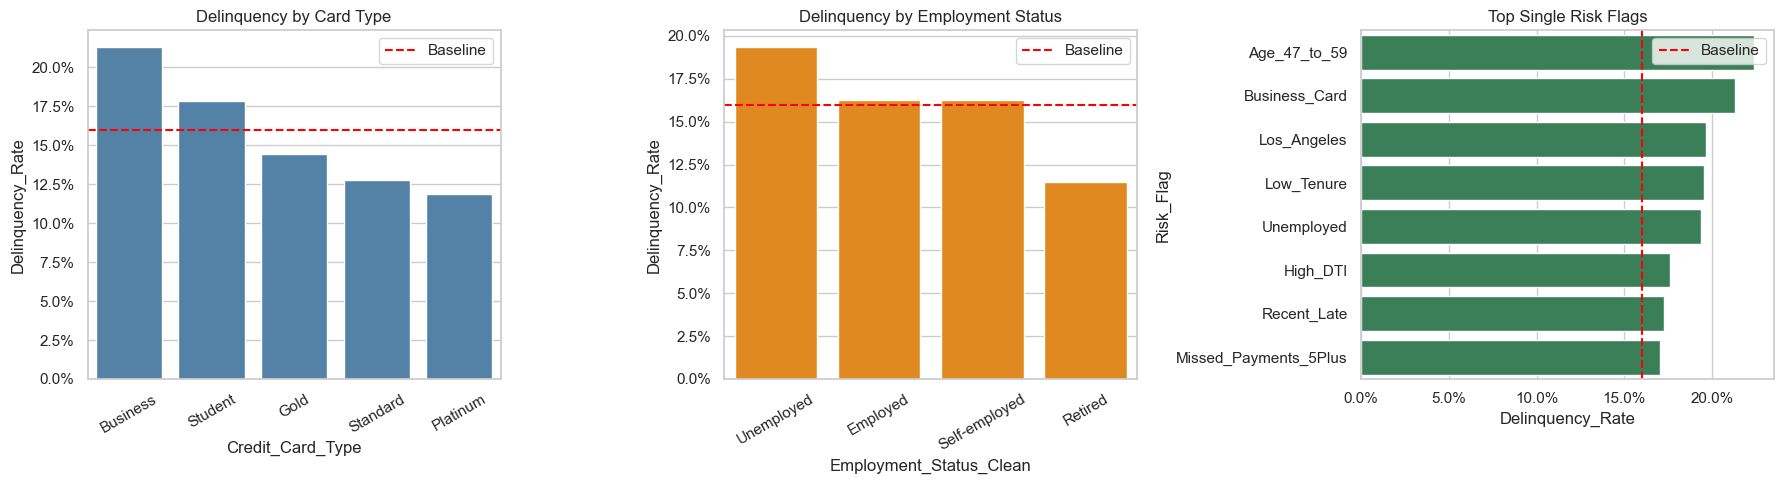

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_cards = category_risk_tables['Credit_Card_Type']
sns.barplot(data=top_cards, x='Credit_Card_Type', y='Delinquency_Rate', ax=axes[0], color='steelblue')
axes[0].axhline(baseline_rate, color='red', linestyle='--', label='Baseline')
axes[0].set_title('Delinquency by Card Type')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

top_emp = category_risk_tables['Employment_Status_Clean']
sns.barplot(data=top_emp, x='Employment_Status_Clean', y='Delinquency_Rate', ax=axes[1], color='darkorange')
axes[1].axhline(baseline_rate, color='red', linestyle='--', label='Baseline')
axes[1].set_title('Delinquency by Employment Status')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

top_flags = single_flag_summary.head(8)
sns.barplot(data=top_flags, y='Risk_Flag', x='Delinquency_Rate', ax=axes[2], color='seagreen')
axes[2].axvline(baseline_rate, color='red', linestyle='--', label='Baseline')
axes[2].set_title('Top Single Risk Flags')
axes[2].xaxis.set_major_formatter(PercentFormatter(1.0))

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

## 14. Key Risk Indicators and Insights

- **Short account tenure:** Customers with tenure below the first quartile have a higher delinquency rate, suggesting new accounts may require closer monitoring.
- **Business credit card type:** Business card customers show the highest delinquency rate among card categories, so card type should be retained as a prediction feature.
- **Unemployed employment status:** Unemployed customers have elevated delinquency risk, likely due to weaker repayment stability.
- **Los Angeles location:** Los Angeles customers show higher delinquency than other locations, which may reflect regional risk or sample-specific behavior.
- **Age 47-59 band:** The middle-older age band has the highest age-based delinquency rate, which is unexpected and should be validated by the analytics team.
- **High debt-to-income ratio:** Customers in the top DTI quartile show above-baseline delinquency, making debt burden a useful risk signal.
- **High credit utilization:** High utilization is only slightly above baseline on its own, but it becomes more useful when combined with tenure, location, or age indicators.
- **Recent late payments:** Late payments in recent months appear more predictive than missed statuses in this dataset and should be tested as a feature.
- **Low tenure plus Los Angeles:** This interaction creates one of the highest-risk customer slices, showing that combined indicators may outperform single variables.
- **Unemployed plus Business card:** This segment has materially higher delinquency than the portfolio average and should be prioritized in model feature engineering.
- **High loan balance plus age 47-59:** This combination shows elevated risk and may capture repayment stress in a specific customer segment.
- **High DTI plus Business card:** Business card users with higher debt burden appear riskier, making this a useful interaction candidate.

## 15. Unexpected Findings for Further Investigation

- **Credit score has a weak and counterintuitive relationship with delinquency**, so the team should confirm whether score values are cleaned correctly and whether zero scores are valid.
- **Missed payments are not strongly predictive in this sample**, which may indicate noisy labels, synthetic data effects, or a mismatch between `Missed_Payments` and the target definition.
- **Some on-time monthly statuses show higher delinquency than late or missed statuses**, so the monthly payment history fields should be validated before modeling.
- **Income does not show a simple monotonic risk pattern**, so income should likely be used with transformations or interaction features rather than as a simple linear predictor.
- **Data quality issues remain relevant**, including zero values in `Income`, `Credit_Score`, and `Loan_Balance`, plus inconsistent employment labels such as `EMP`, `employed`, and `Employed`.

## 16. Modeling Recommendations

- Use both raw variables and engineered flags for tenure, utilization, DTI, payment behavior, and product type.
- Include interaction features because risk becomes clearer when customer attributes are combined.
- Validate unusual patterns before production modeling, especially credit score, missed payments, and monthly status behavior.
- Treat zero values carefully because they may represent missing or placeholder values rather than true financial values.